In [31]:
import numpy as np
import sys, os, pickle
import scipy, sklearn, skimage, math
from scipy import ndimage, signal
import matplotlib.pyplot as plt
import cv2
from skimage import io, data, exposure

In [32]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [33]:
print(sys.version)
print(torch.__version__)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
2.10.0+cu128


In [34]:
# Check the specifications of your machine/what resources you have been allocated through Colab.
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Mar 18 14:24:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [35]:
project_name = '001_quick_test'

# cpu or cuda
device ='cpu'
if torch.cuda.is_available():
    device='cuda:0'
print(device)


cuda:0


In [36]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [37]:
foldername = './my_dataset'
im = io.imread(os.path.join(foldername, '9_Nelson Lake NE1010 Pos 168_K1.jpg'))

In [38]:
print(type(im))
print(im.shape)
print(type(im[0,0]), im.max(), im.min())

<class 'numpy.ndarray'>
(666, 666)
<class 'numpy.uint8'> 255 0


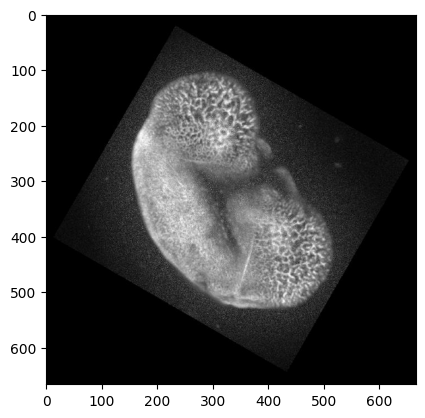

In [39]:
plt.imshow(im, cmap='gray')
